# Classification - XGBoost Classification with Technical Indicators
**Task:** BTC/USDT hourly price direction (up/down) classification  
**Models:** Gradient Boosting from Scratch · XGBoost (library)  
**Extra features:** RSI · MACD · Bollinger Bands · EMA · ATR · ROC · Stochastic · OBV

In [1]:
!pip install xgboost --quiet

In [2]:
import os, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from xgboost import XGBClassifier

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR    = os.path.join(BASE_DIR, 'data')
MODEL_DIR   = os.path.join(BASE_DIR, 'models')
RESULT_DIR  = os.path.join(BASE_DIR, 'results')
RAW_CSV     = os.path.join(BASE_DIR, 'preprocessing-May', 'btc_1h_data_2018_to_2025.csv')

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

RESULTS_CSV = os.path.join(RESULT_DIR, 'classification_results.csv')
RESULTS_COLS = ['model','accuracy','precision','sensitivity','specificity',
                'tnr','f1','roc_auc','tp','tn','fp','fn','recall']

print('BASE_DIR:', BASE_DIR)
print('XGBoost notebook ready.')

BASE_DIR: /Users/mihiniboteju/cryptoflow
XGBoost notebook ready.


In [3]:
# ── Shared utilities (same pattern as all prior notebooks) ────────────────────

def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn, fp, fn, tp = 0, 0, int((y_true == 0).sum()), int((y_true == 1).sum())

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else 0.5

    return {
        'model':       model_name,
        'accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'precision':   round(precision_score(y_true, y_pred, zero_division=0), 4),
        'sensitivity': round(sensitivity, 4),
        'specificity': round(specificity, 4),
        'tnr':         round(specificity, 4),
        'f1':          round(f1_score(y_true, y_pred, zero_division=0), 4),
        'roc_auc':     round(auc, 4),
        'tp':          float(tp),
        'tn':          float(tn),
        'fp':          float(fp),
        'fn':          float(fn),
        'recall':      round(sensitivity, 4),
    }

def save_results(metrics_list):
    new_df = pd.DataFrame(metrics_list, columns=RESULTS_COLS)
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        # Remove old rows for same model names to avoid duplicates
        names = new_df['model'].tolist()
        existing = existing[~existing['model'].isin(names)]
        combined = pd.concat([existing, new_df], ignore_index=True)
    else:
        combined = new_df
    combined.to_csv(RESULTS_CSV, index=False)
    print(f'Results saved → {RESULTS_CSV}')

def plot_confusion_matrix(cm, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Down','Up']); ax.set_yticklabels(['Down','Up'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=12)
    plt.colorbar(im, ax=ax)

print('Utilities loaded.')

Utilities loaded.



## Feature Engineering — Technical Indicators + Temporal Features
We merge the raw OHLCV data with the pre-built features and engineer **4 groups** of new features:

| Group | Features | Count |
|-------|----------|-------|
| **Base indicators** | RSI(14), MACD(12/26/9), Bollinger %B + BW, EMA cross, ATR(14), ROC(10), Stochastic %K/%D, OBV signal | 13 |
| **Lag features** | 1h & 2h lags of RSI, MACD hist, BB %B, ROC, Stoch %K, EMA cross | 12 |
| **Rolling statistics** | Mean & std of log-returns over 6h, 12h, 24h windows | 6 |
| **Time features** | Hour-of-day & day-of-week (sine/cosine cyclical encoding) | 4 |
| **Interaction features** | RSI×MACD, Bollinger×ROC, Stochastic×OBV | 3 |

**Total: 10 original + 38 engineered = 48 features**


In [4]:

# ── 1. Load raw OHLCV ─────────────────────────────────────────────────────────
raw = pd.read_csv(RAW_CSV)
raw.columns = raw.columns.str.strip()
raw['open time'] = pd.to_datetime(raw['Open time'].str.strip())
raw = raw[['open time','Open','High','Low','Close','Volume']].copy()
raw.columns = ['open time','open','high','low','close','volume']
raw = raw.sort_values('open time').reset_index(drop=True)

# ── 2. Technical indicator functions ─────────────────────────────────────────

def rsi(close, period=14):
    delta = close.diff()
    gain  = delta.clip(lower=0).ewm(alpha=1/period, min_periods=period).mean()
    loss  = (-delta.clip(upper=0)).ewm(alpha=1/period, min_periods=period).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

def macd(close, fast=12, slow=26, signal=9):
    ema_fast    = close.ewm(span=fast, adjust=False).mean()
    ema_slow    = close.ewm(span=slow, adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram   = macd_line - signal_line
    return macd_line, signal_line, histogram

def bollinger_bands(close, period=20, num_std=2):
    sma   = close.rolling(period).mean()
    std   = close.rolling(period).std()
    upper = sma + num_std * std
    lower = sma - num_std * std
    pct_b = (close - lower) / (upper - lower + 1e-9)   # %B position
    bw    = (upper - lower) / (sma + 1e-9)              # bandwidth
    return upper, lower, pct_b, bw

def ema(close, span):
    return close.ewm(span=span, adjust=False).mean()

def atr(high, low, close, period=14):
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(alpha=1/period, min_periods=period).mean()

def roc(close, period=10):
    return (close - close.shift(period)) / (close.shift(period) + 1e-9) * 100

def stochastic(high, low, close, k_period=14, d_period=3):
    lowest_low   = low.rolling(k_period).min()
    highest_high = high.rolling(k_period).max()
    pct_k = (close - lowest_low) / (highest_high - lowest_low + 1e-9) * 100
    pct_d = pct_k.rolling(d_period).mean()
    return pct_k, pct_d

def obv(close, volume):
    direction = np.sign(close.diff().fillna(0))
    return (direction * volume).cumsum()

# ── 3. Compute base indicators ────────────────────────────────────────────────
df = raw.copy()

df['rsi_14']          = rsi(df['close'], 14)
df['macd_line'], df['macd_signal'], df['macd_hist'] = macd(df['close'])
df['bb_upper'], df['bb_lower'], df['bb_pct_b'], df['bb_bw'] = bollinger_bands(df['close'])
df['ema_9']           = ema(df['close'], 9)
df['ema_21']          = ema(df['close'], 21)
df['ema_cross']       = df['ema_9'] - df['ema_21']
df['atr_14']          = atr(df['high'], df['low'], df['close'], 14)
df['roc_10']          = roc(df['close'], 10)
df['stoch_k'], df['stoch_d'] = stochastic(df['high'], df['low'], df['close'])
df['stoch_cross']     = df['stoch_k'] - df['stoch_d']
df['obv_raw']         = obv(df['close'], df['volume'])
df['obv_ema']         = df['obv_raw'].ewm(span=21, adjust=False).mean()
df['obv_signal']      = df['obv_raw'] - df['obv_ema']
df['obv_signal_norm'] = df['obv_signal'] / (df['atr_14'] * df['close'] + 1e-9)

# ── 4. Lag features — give XGBoost temporal memory ────────────────────────────
# Lag 1h and 2h for the most informative indicators
for col in ['rsi_14', 'macd_hist', 'bb_pct_b', 'roc_10', 'stoch_k', 'ema_cross']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag2'] = df[col].shift(2)

# ── 5. Rolling statistics on close returns ────────────────────────────────────
df['log_ret']          = np.log(df['close'] / df['close'].shift(1))
df['roll_mean_6h']     = df['log_ret'].rolling(6).mean()
df['roll_std_6h']      = df['log_ret'].rolling(6).std()
df['roll_mean_12h']    = df['log_ret'].rolling(12).mean()
df['roll_std_12h']     = df['log_ret'].rolling(12).std()
df['roll_mean_24h']    = df['log_ret'].rolling(24).mean()
df['roll_std_24h']     = df['log_ret'].rolling(24).std()

# ── 6. Time-of-day & day-of-week (cyclical encoding) ─────────────────────────
df['hour']             = df['open time'].dt.hour
df['dayofweek']        = df['open time'].dt.dayofweek
# Sine/cosine encoding so 23h and 0h are adjacent, not far apart
df['hour_sin']         = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']         = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']          = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos']          = np.cos(2 * np.pi * df['dayofweek'] / 7)

# ── 7. Interaction features — momentum confluence ─────────────────────────────
df['rsi_x_macd']       = (df['rsi_14'] / 100) * df['macd_hist']   # RSI × MACD histogram
df['bb_x_roc']         = df['bb_pct_b'] * df['roc_10']             # Bollinger position × momentum
df['stoch_x_obv']      = (df['stoch_k'] / 100) * df['obv_signal_norm']  # stochastic × volume signal

# ── 8. Collect all new feature columns ───────────────────────────────────────
lag_cols = [f'{c}_{l}' for c in ['rsi_14','macd_hist','bb_pct_b','roc_10','stoch_k','ema_cross']
                                  for l in ['lag1','lag2']]
roll_cols      = ['roll_mean_6h','roll_std_6h','roll_mean_12h','roll_std_12h','roll_mean_24h','roll_std_24h']
time_cols      = ['hour_sin','hour_cos','dow_sin','dow_cos']
interact_cols  = ['rsi_x_macd','bb_x_roc','stoch_x_obv']
base_indicator_cols = [
    'rsi_14','macd_line','macd_signal','macd_hist',
    'bb_pct_b','bb_bw','ema_cross',
    'atr_14','roc_10',
    'stoch_k','stoch_d','stoch_cross',
    'obv_signal_norm'
]
indicator_cols = base_indicator_cols + lag_cols + roll_cols + time_cols + interact_cols

print('Indicators computed. Raw df shape:', df.shape)
print(f'\nFeature groups:')
print(f'  Base indicators : {len(base_indicator_cols)}')
print(f'  Lag features    : {len(lag_cols)}')
print(f'  Rolling stats   : {len(roll_cols)}')
print(f'  Time features   : {len(time_cols)}')
print(f'  Interactions    : {len(interact_cols)}')
print(f'  ─────────────────────────────')
print(f'  Total new       : {len(indicator_cols)}')


Indicators computed. Raw df shape: (70847, 54)

Feature groups:
  Base indicators : 13
  Lag features    : 12
  Rolling stats   : 6
  Time features   : 4
  Interactions    : 3
  ─────────────────────────────
  Total new       : 38


In [5]:

# ── Merge indicators with train / test feature CSVs ───────────────────────────
ORIG_FEATURES = [
    'close_position','return_lag_1h','log_return_1h','gk_avg_3h',
    'log_return_3h','gk_lag_1h','hl_range_pct','trade_intensity',
    'atr_lag_3h','log_return_6h'
]
TARGET = 'target_class'

train_raw = pd.read_csv(os.path.join(DATA_DIR, 'final_training_data_classification_train.csv'))
test_raw  = pd.read_csv(os.path.join(DATA_DIR, 'final_training_data_classification_test.csv'))

train_raw['open time'] = pd.to_datetime(train_raw['open time'])
test_raw['open time']  = pd.to_datetime(test_raw['open time'])

# Merge all computed indicators by timestamp
indicators_df = df[['open time'] + indicator_cols].copy()

train_merged = train_raw.merge(indicators_df, on='open time', how='left')
test_merged  = test_raw.merge(indicators_df,  on='open time', how='left')

ALL_FEATURES = ORIG_FEATURES + indicator_cols

# Drop rows with NaN from lookback windows (mostly start of series)
train_merged = train_merged.dropna(subset=ALL_FEATURES).reset_index(drop=True)
test_merged  = test_merged.dropna(subset=ALL_FEATURES).reset_index(drop=True)

X_train_all = train_merged[ALL_FEATURES].values
y_train_all = train_merged[TARGET].values.astype(int)
X_test      = test_merged[ALL_FEATURES].values
y_test      = test_merged[TARGET].values.astype(int)

# Temporal train / validation split — last 10% of train
val_size = int(len(X_train_all) * 0.10)
X_train, X_val = X_train_all[:-val_size], X_train_all[-val_size:]
y_train, y_val = y_train_all[:-val_size], y_train_all[-val_size:]

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')
print(f'Features: {len(ALL_FEATURES)} total  ({len(ORIG_FEATURES)} original + {len(indicator_cols)} engineered)')

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

scaler_path = os.path.join(MODEL_DIR, 'scaler_xgb.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler saved → {scaler_path}')


Train: (54126, 48)  |  Val: (6014, 48)  |  Test: (10635, 48)
Features: 48 total  (10 original + 38 engineered)
Scaler saved → /Users/mihiniboteju/cryptoflow/models/scaler_xgb.pkl


## Model 1 — Gradient Boosting from Scratch
Manual implementation using **decision stumps** (depth-1 trees) as weak learners.  
Fits each stump to the **negative gradient (pseudo-residuals) of log-loss**.

In [6]:
class DecisionStump:
    """Single-feature, single-threshold binary split (depth-1 tree)."""
    def __init__(self):
        self.feature_idx  = None
        self.threshold    = None
        self.left_value   = None
        self.right_value  = None

    def fit(self, X, residuals):
        """Fit stump to minimise squared error of residuals."""
        n_samples, n_features = X.shape
        best_sse = np.inf

        for f in range(n_features):
            col = X[:, f]
            # Use percentile thresholds for speed (20 candidates per feature)
            thresholds = np.percentile(col, np.linspace(5, 95, 20))
            for thresh in thresholds:
                left_mask  = col <= thresh
                right_mask = ~left_mask
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue
                l_val = residuals[left_mask].mean()
                r_val = residuals[right_mask].mean()
                sse = (
                    ((residuals[left_mask]  - l_val) ** 2).sum() +
                    ((residuals[right_mask] - r_val) ** 2).sum()
                )
                if sse < best_sse:
                    best_sse         = sse
                    self.feature_idx = f
                    self.threshold   = thresh
                    self.left_value  = l_val
                    self.right_value = r_val

    def predict(self, X):
        col = X[:, self.feature_idx]
        return np.where(col <= self.threshold, self.left_value, self.right_value)


class GradientBoostingScratch:
    """
    Gradient Boosting for binary classification (log-loss).
    F_m(x) = F_{m-1}(x) + lr * stump_m(x)
    Pseudo-residuals: r_i = y_i - sigmoid(F_{m-1}(x_i))
    """
    def __init__(self, n_estimators=100, learning_rate=0.1):
        self.n_estimators  = n_estimators
        self.learning_rate = learning_rate
        self.stumps        = []
        self.F0            = None   # initial log-odds

    @staticmethod
    def _sigmoid(x):
        return 1 / (1 + np.exp(-np.clip(x, -30, 30)))

    def fit(self, X, y, verbose=True):
        # Initialise with log-odds of the positive class
        p0 = np.clip(y.mean(), 1e-6, 1 - 1e-6)
        self.F0 = np.log(p0 / (1 - p0))
        F = np.full(len(y), self.F0)

        for m in range(self.n_estimators):
            p           = self._sigmoid(F)          # current probabilities
            residuals   = y - p                     # negative gradient of log-loss
            stump       = DecisionStump()
            stump.fit(X, residuals)
            update      = stump.predict(X)
            F          += self.learning_rate * update
            self.stumps.append(stump)

            if verbose and (m + 1) % 20 == 0:
                train_loss = -np.mean(
                    y * np.log(p + 1e-9) + (1 - y) * np.log(1 - p + 1e-9)
                )
                print(f'  Stump {m+1:3d}/{self.n_estimators} | log-loss: {train_loss:.4f}')

    def predict_proba(self, X):
        F = np.full(len(X), self.F0)
        for stump in self.stumps:
            F += self.learning_rate * stump.predict(X)
        return self._sigmoid(F)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


print('GradientBoostingScratch class defined.')

GradientBoostingScratch class defined.


In [7]:
# ── Train scratch Gradient Boosting ──────────────────────────────────────────
print('Training Gradient Boosting from Scratch (100 stumps) ...')
gb_scratch = GradientBoostingScratch(n_estimators=100, learning_rate=0.1)
gb_scratch.fit(X_train_s, y_train, verbose=True)
print('Training complete.')

Training Gradient Boosting from Scratch (100 stumps) ...
  Stump  20/100 | log-loss: 0.6900
  Stump  40/100 | log-loss: 0.6882
  Stump  60/100 | log-loss: 0.6870
  Stump  80/100 | log-loss: 0.6862
  Stump 100/100 | log-loss: 0.6856
Training complete.



── Gradient Boosting Scratch ─────────────────
  model          : GB Scratch
  accuracy       : 0.5254
  precision      : 0.5253
  sensitivity    : 0.5945
  specificity    : 0.4554
  tnr            : 0.4554
  f1             : 0.5578
  roc_auc        : 0.5405
  tp             : 3183.0
  tn             : 2405.0
  fp             : 2876.0
  fn             : 2171.0
  recall         : 0.5945


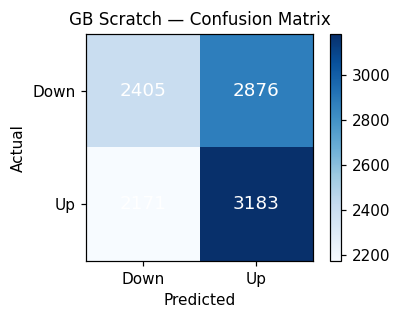

Model saved → models/gb_scratch.pkl


In [8]:
# ── Evaluate scratch model ────────────────────────────────────────────────────
y_prob_scratch = gb_scratch.predict_proba(X_test_s)
y_pred_scratch = gb_scratch.predict(X_test_s)

metrics_scratch = compute_metrics('GB Scratch', y_test, y_pred_scratch, y_prob_scratch)

print('\n── Gradient Boosting Scratch ─────────────────')
for k, v in metrics_scratch.items():
    print(f'  {k:15s}: {v}')

# Confusion matrix
cm_scratch = confusion_matrix(y_test, y_pred_scratch)
fig, ax = plt.subplots(figsize=(4, 3))
plot_confusion_matrix(cm_scratch, 'GB Scratch — Confusion Matrix', ax=ax)
plt.tight_layout()
plt.show()

# Save model
with open(os.path.join(MODEL_DIR, 'gb_scratch.pkl'), 'wb') as f:
    pickle.dump(gb_scratch, f)
print('Model saved → models/gb_scratch.pkl')

## Model 2 — XGBoost (Library)
`XGBClassifier` with **early stopping** on the validation AUC, `subsample` and `colsample_bytree` regularisation.

In [9]:
# ── Train XGBoost library model ───────────────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators        = 500,
    learning_rate       = 0.05,
    max_depth           = 6,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    min_child_weight    = 5,
    gamma               = 0.1,
    reg_alpha           = 0.1,
    reg_lambda          = 1.0,
    eval_metric         = 'auc',
    early_stopping_rounds = 30,
    random_state        = 42,
    verbosity           = 0,
    use_label_encoder   = False,
)

print('Training XGBoost (up to 500 trees, early stop on val AUC) ...')
xgb_model.fit(
    X_train_s, y_train,
    eval_set=[(X_val_s, y_val)],
    verbose=50
)
best_iter = xgb_model.best_iteration
print(f'\nBest iteration: {best_iter}')

Training XGBoost (up to 500 trees, early stop on val AUC) ...
[0]	validation_0-auc:0.54299
[42]	validation_0-auc:0.55975

Best iteration: 12



── XGBoost ───────────────────────────────────
  model          : XGBoost
  accuracy       : 0.5331
  precision      : 0.5314
  sensitivity    : 0.6152
  specificity    : 0.4499
  tnr            : 0.4499
  f1             : 0.5702
  roc_auc        : 0.5464
  tp             : 3294.0
  tn             : 2376.0
  fp             : 2905.0
  fn             : 2060.0
  recall         : 0.6152


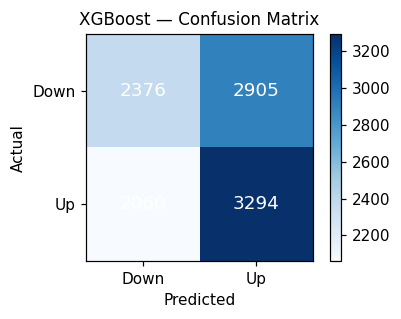

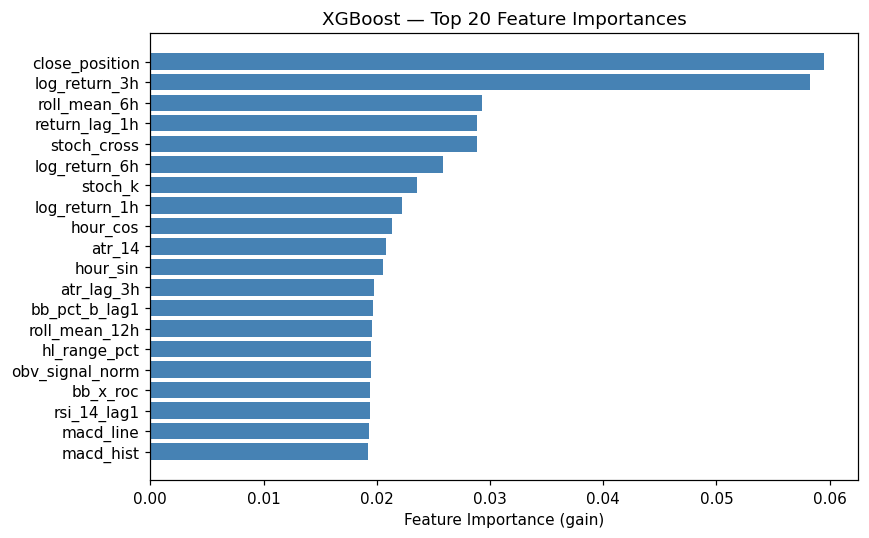

Model saved → models/xgb_model.pkl


In [10]:
# ── Evaluate XGBoost ──────────────────────────────────────────────────────────
y_prob_xgb = xgb_model.predict_proba(X_test_s)[:, 1]
y_pred_xgb = xgb_model.predict(X_test_s)

metrics_xgb = compute_metrics('XGBoost', y_test, y_pred_xgb, y_prob_xgb)

print('\n── XGBoost ───────────────────────────────────')
for k, v in metrics_xgb.items():
    print(f'  {k:15s}: {v}')

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(4, 3))
plot_confusion_matrix(cm_xgb, 'XGBoost — Confusion Matrix', ax=ax)
plt.tight_layout()
plt.show()

# ── Feature importance (top 20) ───────────────────────────────────────────────
importances = xgb_model.feature_importances_
feat_df = pd.DataFrame({'feature': ALL_FEATURES, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color='steelblue')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost — Top 20 Feature Importances')
plt.tight_layout()
plt.show()

# Save model
with open(os.path.join(MODEL_DIR, 'xgb_model.pkl'), 'wb') as f:
    pickle.dump(xgb_model, f)
print('Model saved → models/xgb_model.pkl')

## Results — ROC Curves, Metrics Table & CSV Export

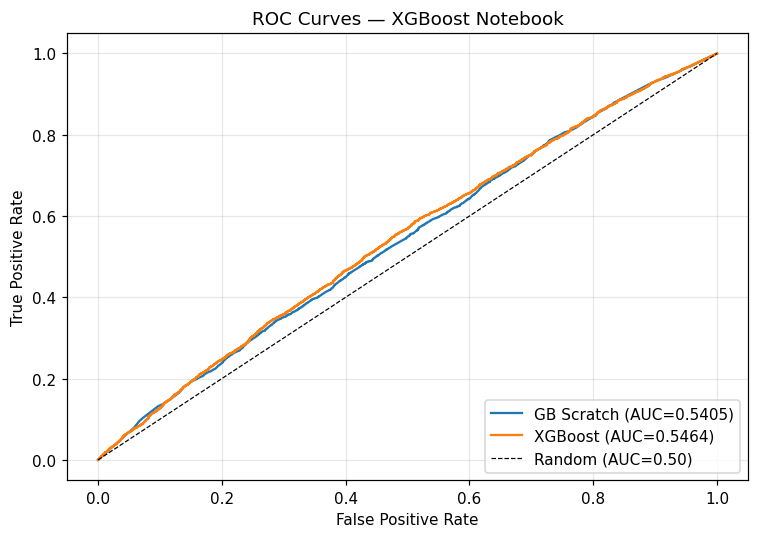

Results saved → /Users/mihiniboteju/cryptoflow/results/classification_results.csv

── XGboost Summary ──────────────────────────────────────
     model  accuracy  precision  sensitivity  specificity     f1  roc_auc
GB Scratch    0.5254     0.5253       0.5945       0.4554 0.5578   0.5405
   XGBoost    0.5331     0.5314       0.6152       0.4499 0.5702   0.5464

── All Models (results/classification_results.csv) ──────────
                                  model  accuracy  precision  sensitivity  specificity     f1  roc_auc
                Majority Class Baseline    0.5034     0.5034       1.0000       0.0000 0.6697   0.5000
          Logistic Regression (Scratch)    0.5236     0.5265       0.5334       0.5137 0.5300   0.5388
          Logistic Regression (sklearn)    0.5247     0.5275       0.5347       0.5145 0.5311   0.5386
                Decision Tree (Scratch)    0.5296     0.5327       0.5334       0.5257 0.5331   0.5295
        Decision Tree sklearn (depth=3)    0.5308     0.530

In [12]:
# ── ROC comparison ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

for label, y_prob in [
    ('GB Scratch', y_prob_scratch),
    ('XGBoost',    y_prob_xgb),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc_val:.4f})')

ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — XGBoost Notebook')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Save results to CSV ───────────────────────────────────────────────────────
all_metrics = [metrics_scratch, metrics_xgb]
save_results(all_metrics)

# ── Summary table ─────────────────────────────────────────────────────────────
summary_df = pd.DataFrame(all_metrics, columns=RESULTS_COLS)
display_cols = ['model','accuracy','precision','sensitivity','specificity','f1','roc_auc']
print('\n── XGboost Summary ──────────────────────────────────────')
print(summary_df[display_cols].to_string(index=False))

# ── Full results table (all notebooks) ───────────────────────────────────────
print('\n── All Models (results/classification_results.csv) ──────────')
all_results = pd.read_csv(RESULTS_CSV)
print(all_results[display_cols].to_string(index=False))